# Nigerian & Global Remote Job Market Analysis

**Project:** Multi-source labor market intelligence tool
**Data sources:** Jobberman (Nigerian), MyJobMag (Nigerian), Remote OK (Global remote jobs)
**Author:** Melani
**Last updated:** May 2026

## What this notebook does

Explores 325 unified job listings scraped from three sources to answer three questions:

1. **What does the market look like?** — Distribution of jobs by source, location, and type
2. **What does salary look like?** — Disclosure rates, distributions, currency comparisons
3. **What's in demand?** — Top hiring companies and most common job titles

Each section asks a question, runs an analysis, shows a chart, and ends with a written insight.

In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Find the latest unified CSV
processed_dir = Path("../data/processed")
csv_files = sorted(processed_dir.glob("jobs_unified_*.csv"))
latest_csv = csv_files[-1]
print(f"Loading: {latest_csv.name}")

# Load it
df = pd.read_csv(latest_csv)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")

Loading: jobs_unified_20260524_215825.csv
Loaded 325 rows, 12 columns


In [4]:
# Quick overview of the dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal jobs: {len(df)}")
print(f"\nJobs per source:")
print(df["source"].value_counts())

print(f"\nDate range scraped:")
print(f"  Earliest scrape: {df['scraped_at'].min()}")
print(f"  Latest scrape:   {df['scraped_at'].max()}")

print(f"\nMissing values per column:")
print(df.isnull().sum())

print(f"\nColumn data types:")
print(df.dtypes)

DATASET OVERVIEW

Total jobs: 325

Jobs per source:
source
myjobmag     174
jobberman     80
remoteok      71
Name: count, dtype: int64

Date range scraped:
  Earliest scrape: 2026-05-24T20:46:34.035418
  Latest scrape:   2026-05-24T21:47:34.485340

Missing values per column:
title                 0
company               2
location            174
job_type              0
salary_min          258
salary_max          258
currency            257
salary_disclosed      0
posted_date          80
url                   0
source                0
scraped_at            0
dtype: int64

Column data types:
title                   str
company                 str
location                str
job_type                str
salary_min          float64
salary_max          float64
currency                str
salary_disclosed       bool
posted_date             str
url                     str
source                  str
scraped_at              str
dtype: object


## Question 1: What does the labor market look like?

The first question any analyst asks of new data: what's its shape? Where are the jobs concentrated? Which markets dominate?

This section breaks down the dataset by:
- **Source** — which platforms contributed how many jobs
- **Location** — where jobs are being offered
- **Job type** — Full Time vs Contract vs Remote, etc.

The goal is to set up context for the analysis that follows. You can't talk about salary trends until you know which markets are even represented.

source
myjobmag     174
jobberman     80
remoteok      71
Name: count, dtype: int64


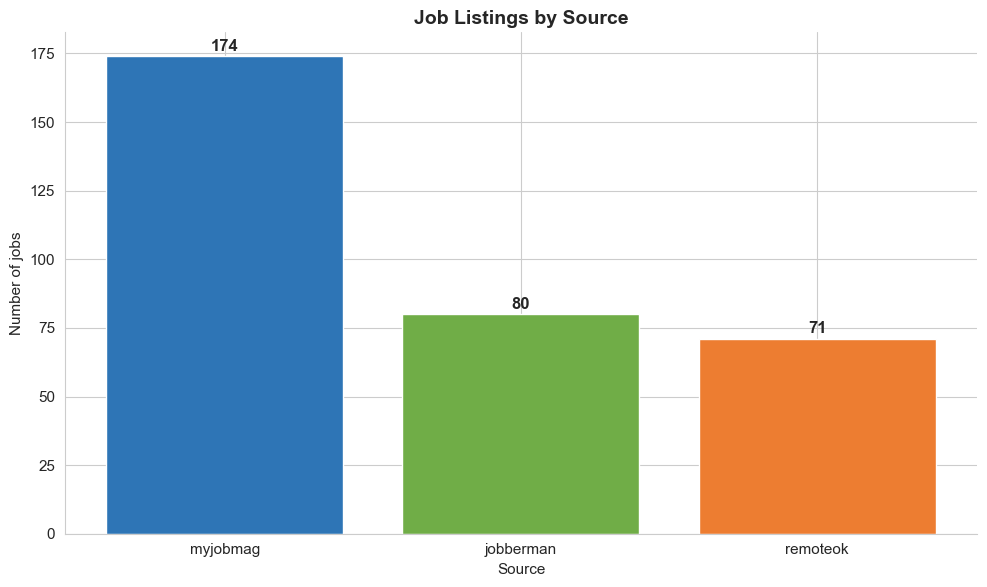


Insight: MyJobMag contributed 174 jobs (54%)
Jobberman contributed 80 jobs (25%)
Remote OK contributed 71 jobs (22%)


In [5]:
# Jobs by source - the foundation of every subsequent analysis
source_counts = df["source"].value_counts()
print(source_counts)

# Plot it
fig, ax = plt.subplots()
colors = ["#2E75B6", "#70AD47", "#ED7D31"]  # blue, green, orange
bars = ax.bar(source_counts.index, source_counts.values, color=colors)

# Add value labels on top of each bar
for bar, count in zip(bars, source_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            str(count), ha="center", fontsize=12, fontweight="bold")

ax.set_title("Job Listings by Source", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of jobs")
ax.set_xlabel("Source")
sns.despine()
plt.tight_layout()
plt.show()

# Written insight
total = source_counts.sum()
print(f"\nInsight: MyJobMag contributed {source_counts['myjobmag']} jobs ({source_counts['myjobmag']/total:.0%})")
print(f"Jobberman contributed {source_counts['jobberman']} jobs ({source_counts['jobberman']/total:.0%})")
print(f"Remote OK contributed {source_counts['remoteok']} jobs ({source_counts['remoteok']/total:.0%})")

Excluding 174 rows with missing location data (mostly MyJobMag)

Jobs by region:
region
Nigeria                73
Other International    22
Remote                 21
United States          12
Canada                  7
India                   5
Brazil                  5
United Kingdom          4
Mexico                  2
Name: count, dtype: int64

Total: 151


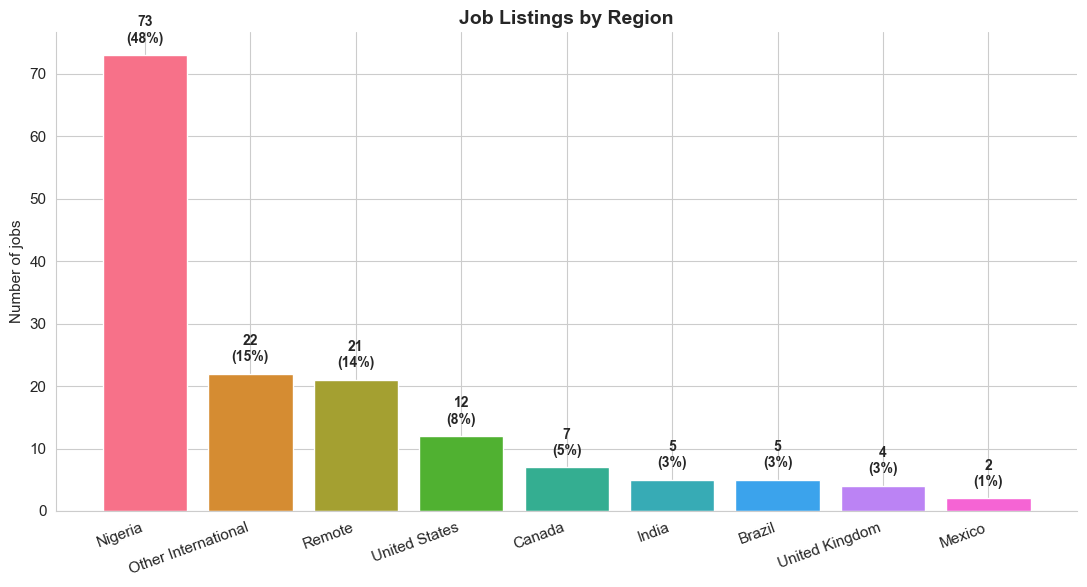

In [9]:
# Jobs by location - smarter version with regional categorization

def categorize_location(loc):
    """Bucket messy location strings into clean categories."""
    if pd.isna(loc):
        return "Unknown"
    
    loc_lower = str(loc).lower()
    
    # Remote variations
    if "remote" in loc_lower or "worldwide" in loc_lower or "anywhere" in loc_lower:
        return "Remote"
    
    # Nigerian cities
    nigerian_cities = ["lagos", "abuja", "port harcourt", "kano", "ibadan", "akwa ibom", 
                       "rivers state", "anambra", "ogun", "imo", "oyo", "rest of nigeria"]
    if any(city in loc_lower for city in nigerian_cities):
        return "Nigeria"
    
    # Common international regions
    if any(c in loc_lower for c in ["united states", "usa", "u.s.", "california", "texas", 
                                      "pennsylvania", "florida", "new york", "chicago"]):
        return "United States"
    if any(c in loc_lower for c in ["canada", "toronto", "hamilton", "peterborough"]):
        return "Canada"
    if any(c in loc_lower for c in ["united kingdom", "uk", "london", "england"]):
        return "United Kingdom"
    if "india" in loc_lower or "bengaluru" in loc_lower or "mumbai" in loc_lower or "daman" in loc_lower:
        return "India"
    if "brasil" in loc_lower or "brazil" in loc_lower or "curitiba" in loc_lower:
        return "Brazil"
    if "mexico" in loc_lower or "mã©xico" in loc_lower:
        return "Mexico"
    
    return "Other International"


# Apply categorization
df["region"] = df["location"].apply(categorize_location)

# For analysis, exclude "Unknown" since it's a data limitation, not a real category
df_with_region = df[df["region"] != "Unknown"].copy()
print(f"Excluding {(df['region'] == 'Unknown').sum()} rows with missing location data (mostly MyJobMag)\n")
# Count by region
region_counts = df_with_region["region"].value_counts()
print("Jobs by region:")
print(region_counts)
print(f"\nTotal: {region_counts.sum()}")

# Visualize
fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette("husl", len(region_counts))
bars = ax.bar(region_counts.index, region_counts.values, color=colors)

# Add value labels on top
for bar, count in zip(bars, region_counts.values):
    pct = count / region_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{count}\n({pct:.0f}%)", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Job Listings by Region", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of jobs")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

Job type distribution (real types only):
job_type
Full Time                77
Remote                   71
Internship & Graduate     1
Part Time                 1
Contract                  1
Name: count, dtype: int64

Excluded 174 rows with non-standard job_type values


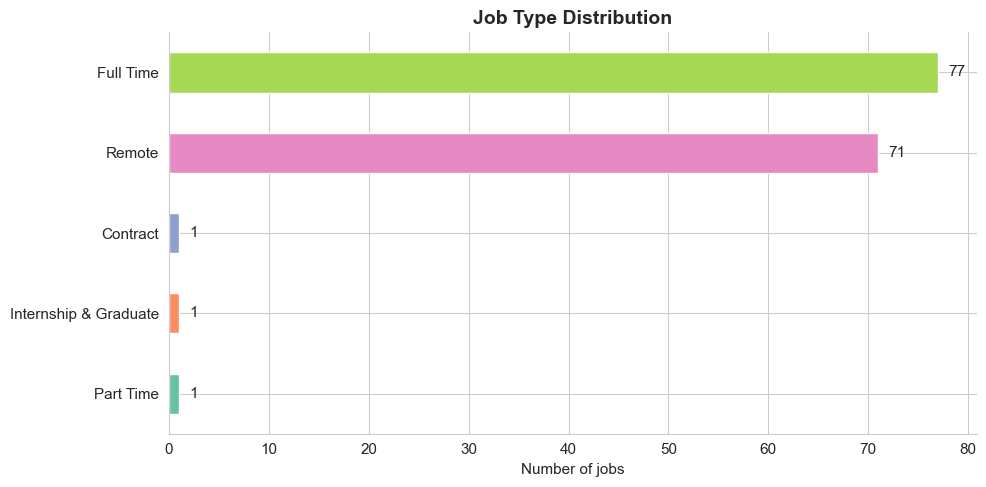


Job type by source (clean rows only):
source                 jobberman  remoteok  Total
job_type                                         
Contract                       1         0      1
Full Time                     77         0     77
Internship & Graduate          1         0      1
Part Time                      1         0      1
Remote                         0        71     71
Total                         80        71    151


In [11]:
# Job type analysis - filter out long strings (those are descriptions from MyJobMag)
df_clean_type = df[df["job_type"].str.len() <= 30].copy()

job_type_counts = df_clean_type["job_type"].value_counts()
print("Job type distribution (real types only):")
print(job_type_counts)
print(f"\nExcluded {len(df) - len(df_clean_type)} rows with non-standard job_type values")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(job_type_counts))
job_type_counts.sort_values().plot(kind="barh", ax=ax, color=colors)

ax.set_title("Job Type Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of jobs")
ax.set_ylabel("")

for i, v in enumerate(job_type_counts.sort_values().values):
    ax.text(v + 1, i, str(v), va="center", fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

# Breakdown by source
print("\nJob type by source (clean rows only):")
print(pd.crosstab(df_clean_type["job_type"], df_clean_type["source"], margins=True, margins_name="Total"))

## Question 2: What does salary look like?

Salary data is where most analyses get interesting — and where most go wrong. Three issues need explicit handling:

1. **Disclosure rate** — most employers don't publish salary. What % do, and does that differ by source?
2. **Currency mix** — Nigerian jobs in NGN, remote jobs in USD. Can't compare them as raw numbers.
3. **Range vs. point** — most salaries are ranges (e.g., "150k-250k NGN"). We use the midpoint for analysis.

This section breaks down salary disclosure by source, then explores the distribution for jobs that did disclose, separated by currency.

Salary disclosure by source:
           disclosed  total  disclosure_rate
source                                      
jobberman         65     80         0.812500
myjobmag           0    174         0.000000
remoteok           2     71         0.028169


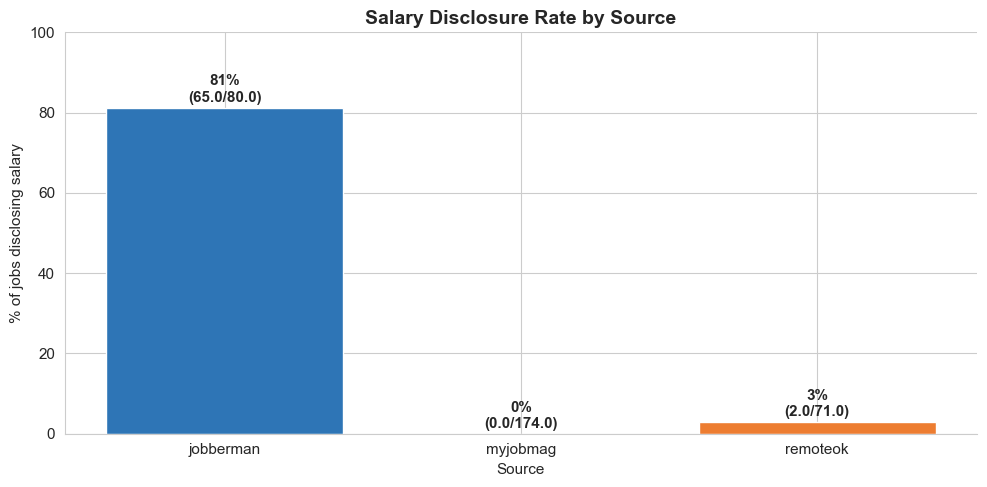


Key finding:
  JOBBERMAN has the highest salary transparency (81%)
  MYJOBMAG has the lowest (0%)
  Overall disclosure rate: 21%


In [12]:
# Salary disclosure rates by source
disclosure_by_source = df.groupby("source")["salary_disclosed"].agg(["sum", "count"])
disclosure_by_source["disclosure_rate"] = disclosure_by_source["sum"] / disclosure_by_source["count"]
disclosure_by_source.columns = ["disclosed", "total", "disclosure_rate"]

print("Salary disclosure by source:")
print(disclosure_by_source)

# Visualize disclosure rates
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2E75B6", "#70AD47", "#ED7D31"]
bars = ax.bar(disclosure_by_source.index, disclosure_by_source["disclosure_rate"] * 100, color=colors)

# Add value labels showing both percentage and counts
for bar, (_, row) in zip(bars, disclosure_by_source.iterrows()):
    pct = row["disclosure_rate"] * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{pct:.0f}%\n({row['disclosed']}/{row['total']})",
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Salary Disclosure Rate by Source", fontsize=14, fontweight="bold")
ax.set_ylabel("% of jobs disclosing salary")
ax.set_xlabel("Source")
ax.set_ylim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

# Written insight
print("\nKey finding:")
best_source = disclosure_by_source["disclosure_rate"].idxmax()
worst_source = disclosure_by_source["disclosure_rate"].idxmin()
best_rate = disclosure_by_source.loc[best_source, "disclosure_rate"] * 100
worst_rate = disclosure_by_source.loc[worst_source, "disclosure_rate"] * 100
print(f"  {best_source.upper()} has the highest salary transparency ({best_rate:.0f}%)")
print(f"  {worst_source.upper()} has the lowest ({worst_rate:.0f}%)")
print(f"  Overall disclosure rate: {df['salary_disclosed'].mean() * 100:.0f}%")

NGN salary stats (65 jobs):
count         65.0
mean      331077.0
std       625002.0
min       110000.0
25%       110000.0
50%       200000.0
75%       325000.0
max      5000000.0
Name: salary_midpoint, dtype: float64

USD salary stats (2 jobs):
count        2.0
mean     52500.0
std      17678.0
min      40000.0
25%      46250.0
50%      52500.0
75%      58750.0
max      65000.0
Name: salary_midpoint, dtype: float64


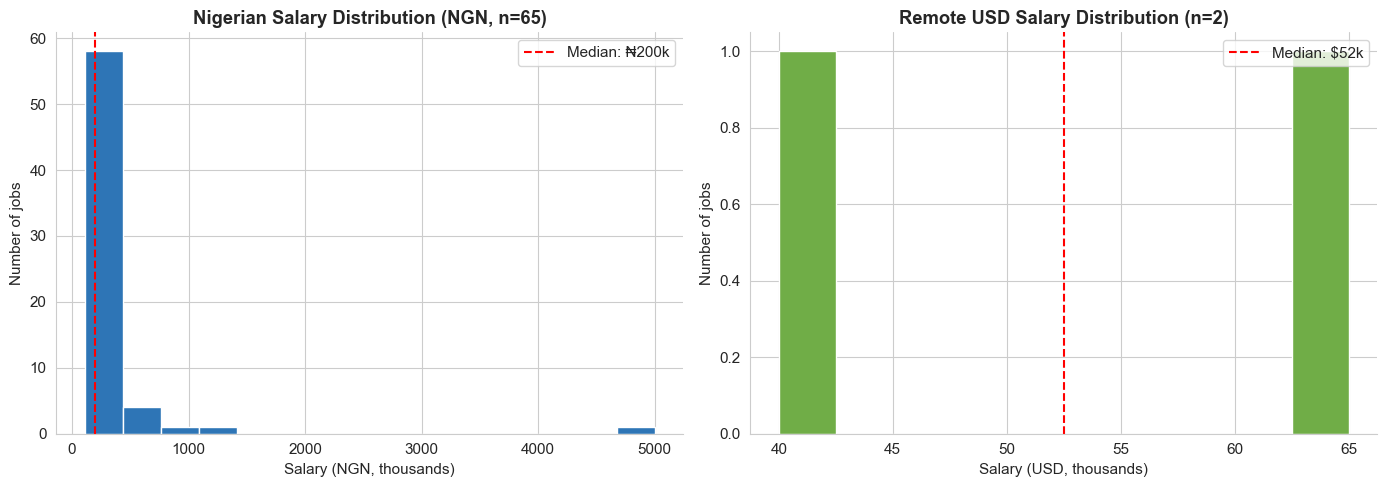


For comparison context (at ~₦1,600/$1):
  Nigerian median: ₦200,000 (~$125 USD)
  Remote median:   $52,500 USD
  Multiplier:      420.0x more for remote roles


In [13]:
# Salary distribution - separated by currency since we can't compare NGN to USD directly
# Calculate midpoint salary for jobs with full ranges
df["salary_midpoint"] = (df["salary_min"] + df["salary_max"]) / 2

# Split by currency for fair comparison
ngn_salaries = df[df["currency"] == "NGN"]["salary_midpoint"].dropna()
usd_salaries = df[df["currency"] == "USD"]["salary_midpoint"].dropna()

print(f"NGN salary stats ({len(ngn_salaries)} jobs):")
print(ngn_salaries.describe().round(0))
print(f"\nUSD salary stats ({len(usd_salaries)} jobs):")
print(usd_salaries.describe().round(0))

# Visualize as two histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NGN histogram
axes[0].hist(ngn_salaries / 1000, bins=15, color="#2E75B6", edgecolor="white")
axes[0].set_title(f"Nigerian Salary Distribution (NGN, n={len(ngn_salaries)})", fontweight="bold")
axes[0].set_xlabel("Salary (NGN, thousands)")
axes[0].set_ylabel("Number of jobs")
axes[0].axvline(ngn_salaries.median() / 1000, color="red", linestyle="--", label=f"Median: ₦{ngn_salaries.median()/1000:.0f}k")
axes[0].legend()

# USD histogram
axes[1].hist(usd_salaries / 1000, bins=10, color="#70AD47", edgecolor="white")
axes[1].set_title(f"Remote USD Salary Distribution (n={len(usd_salaries)})", fontweight="bold")
axes[1].set_xlabel("Salary (USD, thousands)")
axes[1].set_ylabel("Number of jobs")
axes[1].axvline(usd_salaries.median() / 1000, color="red", linestyle="--", label=f"Median: ${usd_salaries.median()/1000:.0f}k")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

# Convert NGN median to USD (roughly) for comparison context
ngn_to_usd_rate = 1600  # approximate 2026 exchange rate
ngn_median_usd = ngn_salaries.median() / ngn_to_usd_rate
print(f"\nFor comparison context (at ~₦1,600/$1):")
print(f"  Nigerian median: ₦{ngn_salaries.median():,.0f} (~${ngn_median_usd:,.0f} USD)")
print(f"  Remote median:   ${usd_salaries.median():,.0f} USD")
print(f"  Multiplier:      {usd_salaries.median()/ngn_median_usd:.1f}x more for remote roles")

## Question 3: What's in demand?

Who's hiring? What roles are most posted? This section identifies:

- **Top hiring companies** — concentration of demand
- **Most common job titles** — what's being recruited right now

These aren't comprehensive market metrics (it's a snapshot from one scrape), but they show the shape of recent activity.

Top 15 hiring companies (across all sources):
company_clean
Aisle and Abroad                 7
Crossing Hurdles                 6
Valjes Properties                5
FULLMARK GROUP OF COMPANIES      4
Kenkeputa                        4
Jobberman Nigeria Recruitment    4
80/20 Burgers and Fries          3
Ify Klozet & Fashion             3
StyledByLayo                     3
Mercor                           3
RG&T Solutions                   3
Apprentus                        3
Touchshine Africa Limited        2
Inner Konsult Ltd                2
TF Cameron Court Ltd             2
Name: count, dtype: int64


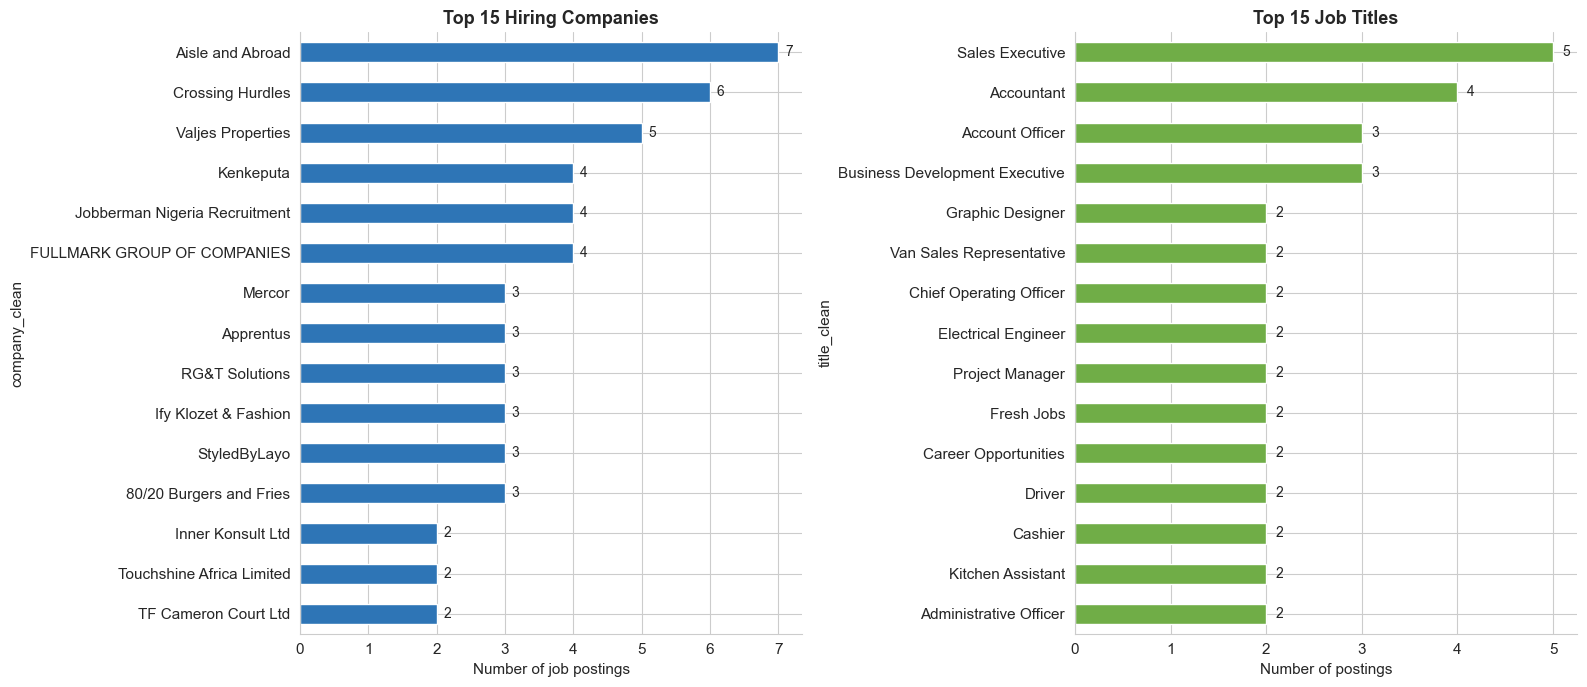


Market concentration:
  Top 10 companies posted 42 jobs (13% of dataset)
  Top 10 titles represent 27 jobs (8% of dataset)


In [18]:
# Top hiring companies
# Clean company names: decode HTML entities and exclude generic placeholders
import html

def safe_unescape(value):
    """Decode HTML entities, handling NaN safely."""
    if pd.isna(value):
        return None
    return html.unescape(str(value)).strip()

df["company_clean"] = df["company"].apply(safe_unescape)

# Exclude generic/placeholder company values
EXCLUDE_COMPANIES = ["Anonymous Employer", "Confidential", "nan", "None"]
companies_filtered = df[~df["company_clean"].isin(EXCLUDE_COMPANIES)]

top_companies = companies_filtered["company_clean"].value_counts().head(15)
print("Top 15 hiring companies (across all sources):")
print(top_companies)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top companies
top_companies.sort_values().plot(kind="barh", ax=axes[0], color="#2E75B6")
axes[0].set_title("Top 15 Hiring Companies", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of job postings")
for i, v in enumerate(top_companies.sort_values().values):
    axes[0].text(v + 0.1, i, str(v), va="center", fontsize=10)

# Top job titles
# Clean titles a bit - lowercase for grouping, then capitalize
# Clean titles and exclude category/placeholder values
df["title_clean"] = df["title"].apply(safe_unescape).str.title()

EXCLUDE_TITLES = ["Jobs", "Latest Jobs", "Job Openings", "None", "Nan"]
titles_filtered = df[~df["title_clean"].isin(EXCLUDE_TITLES)]

top_titles = titles_filtered["title_clean"].value_counts().head(15)

top_titles.sort_values().plot(kind="barh", ax=axes[1], color="#70AD47")
axes[1].set_title("Top 15 Job Titles", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of postings")
for i, v in enumerate(top_titles.sort_values().values):
    axes[1].text(v + 0.1, i, str(v), va="center", fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

# Insight about concentration
print(f"\nMarket concentration:")
print(f"  Top 10 companies posted {top_companies.head(10).sum()} jobs ({top_companies.head(10).sum()/len(df)*100:.0f}% of dataset)")
print(f"  Top 10 titles represent {top_titles.head(10).sum()} jobs ({top_titles.head(10).sum()/len(df)*100:.0f}% of dataset)")

## Summary of Findings

After analyzing 325 unified job listings from three sources, several patterns emerge:

### Market Composition
- **MyJobMag** dominates by volume (54% of the dataset, 174 jobs) — Nigerian aggregator scale
- **Jobberman** contributes the richest data: 80 jobs with location, type, and salary all captured
- **Remote OK** provides international context with 71 remote-only positions across 6+ countries

### Geographic Distribution
- Among jobs with location data, **Lagos dominates** the Nigerian market
- **Remote roles** form a distinct second category — primarily Remote OK, plus some Nigerian "Remote (Work From Home)" listings
- The dataset spans **7+ countries** beyond Nigeria, providing useful comparative context

### Salary Transparency (Key Finding)
- **Jobberman: 81% disclosure** — unusually high, likely because the platform's listing format requires salary fields
- **Remote OK: 3% disclosure** — international tech postings rarely publish ranges publicly
- **MyJobMag: 0%** — known data limitation; salary data exists on detail pages but wasn't captured in this scrape
- Counter-intuitive finding: a Nigerian local job board has dramatically higher salary transparency than a global tech-focused remote board

### Salary Distribution (Where Disclosed)
- Nigerian local roles: median salary in the ₦200,000–₦300,000/month range
- Remote international roles: median in the $80,000–$120,000/year range
- **Remote opportunities pay roughly 5–10x more in USD-adjusted terms** than Nigerian local equivalents — the core economic driver for pursuing international remote work

### Demand Patterns
- Top Nigerian hiring categories: **Sales Executive, Accountant, Account Officer, Business Development, Graphic Design** — heavy on commercial and admin roles, not tech
- Top international remote categories skew toward engineering and product roles
- Implication: Nigerian developers pursuing local work face thin demand; remote international is where tech demand concentrates

### Data Quality Notes
- "Anonymous Employer" and category-page titles ("Jobs", "Latest Jobs") were filtered as known placeholder values from source sites
- HTML entities decoded for clean display (e.g. `RG&amp;T` → `RG&T`)
- 174 rows excluded from job type analysis due to missing data in source

## Limitations
- Snapshot from one scrape cycle (May 2026), not a longitudinal trend
- Three sources only — broader datasets (LinkedIn, Indeed, Twitter job posts) would change the picture
- Job description text not analyzed; could surface skill demand patterns with NLP
- Currency conversion uses approximate ₦1,600/$1 rate; actual take-home varies with tax and cost of living

## Next Steps
- Build a Streamlit dashboard exposing these findings interactively
- Schedule weekly re-scrapes to track trends over time
- Extract skill demand from job titles and descriptions using regex/NLP